# 자전거 대여 수요 예측

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
data_path = "/content/drive/MyDrive/PythonMLWorkspace/06.Bike_Rental_Demand/"

train = pd.read_csv(data_path + "train.csv")
test = pd.read_csv(data_path + "test.csv")

## 데이터 확인

In [25]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [26]:
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


## DataFrame 각 열의 결측값이 몇 개인지, 데이터 타입은 무엇인지 파악

In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


## 피처 엔지니어링

### datetime (object 타입) 을 분석

In [28]:
print(train["datetime"][100])
print(train["datetime"][100].split())
print(train["datetime"][100].split()[0]) # 날짜 
print(train["datetime"][100].split()[1]) # 시간


2011-01-05 09:00:00
['2011-01-05', '09:00:00']
2011-01-05
09:00:00


In [29]:
print(train["datetime"][100].split()[0])
print(train["datetime"][100].split()[0].split("-"))
print(train["datetime"][100].split()[0].split("-")[0]) # 연도
print(train["datetime"][100].split()[0].split("-")[1]) # 월
print(train["datetime"][100].split()[0].split("-")[2]) # 일

2011-01-05
['2011', '01', '05']
2011
01
05


In [30]:
print(train["datetime"][100].split()[1])
print(train["datetime"][100].split()[1].split(":"))
print(train["datetime"][100].split()[1].split(":")[0]) # 시간
print(train["datetime"][100].split()[1].split(":")[1]) # 분
print(train["datetime"][100].split()[1].split(":")[2]) # 초

09:00:00
['09', '00', '00']
09
00
00


In [31]:
train["date"] = train["datetime"].apply(lambda x: x.split()[0]) # 날짜 피처 생성

train["year"] = train["datetime"].apply(lambda x: x.split()[0].split("-")[0])
train["month"] = train["datetime"].apply(lambda x: x.split()[0].split("-")[1])
train["day"] = train["datetime"].apply(lambda x: x.split()[0].split("-")[2])
train["hour"] = train["datetime"].apply(lambda x: x.split()[1].split(":")[0])
train["minute"] = train["datetime"].apply(lambda x: x.split()[1].split(":")[1])
train["second"] = train["datetime"].apply(lambda x: x.split()[1].split(":")[2])


### (아래 코드) calendar 와 datetime 라이브러리를 사용하면 요일 피처를 문자로 구할 수 있다.
### 0은 월요일, 1은 화요일 순으로 매핑이 된다. 
### 단, 모델을 훈련할 때는 피처 값을 문자로 바꾸면 안된다. (머신러닝은 숫자만 인식)

In [32]:
from datetime import datetime
import calendar

print(train["date"][100])
print(datetime.strptime(train["date"][100], "%Y-%m-%d")) # datetime으로 변경

#정수로 요일 변환
print(datetime.strptime(train["date"][100], "%Y-%m-%d").weekday())

#문자열로 요일 변환
print(calendar.day_name[datetime.strptime(train["date"][100], "%Y-%m-%d").weekday()])


2011-01-05
2011-01-05 00:00:00
2
Wednesday


In [33]:
train["weekday"] = train["date"].apply(lambda dateString: calendar.day_name[datetime.strptime(dateString, "%Y-%m-%d").weekday()])

### season, weather 라는 범주형 데이터 (현재 1,2,3,4 로 표현) 를 의미가 잘 드러나도록 map() 함수를 통해 문자열로.

In [34]:
train["season"] = train["season"].map({1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"})
train["weather"] = train["weather"].map({1: "Clear", 2: "Mist, Few Clouds", 3: "Light Snow, Rain, Thunderstorm", 4: "Heavy Rain, Thunderstorm, Snow, Fog"})


In [35]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,year,month,day,hour,minute,second,weekday
0,2011-01-01 00:00:00,Spring,0,0,Clear,9.84,14.395,81,0.0,3,13,16,2011-01-01,2011,01,01,00,00,00,Saturday
1,2011-01-01 01:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0,8,32,40,2011-01-01,2011,01,01,01,00,00,Saturday
2,2011-01-01 02:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0,5,27,32,2011-01-01,2011,01,01,02,00,00,Saturday
3,2011-01-01 03:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0,3,10,13,2011-01-01,2011,01,01,03,00,00,Saturday
4,2011-01-01 04:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0,0,1,1,2011-01-01,2011,01,01,04,00,00,Saturday


# 데이터 시각화

In [38]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

### 분포도

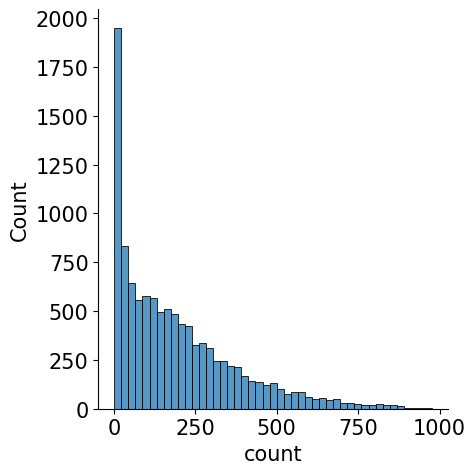

In [ ]:
mpl.rc("font", size=15)
sns.displot(train["count"]);

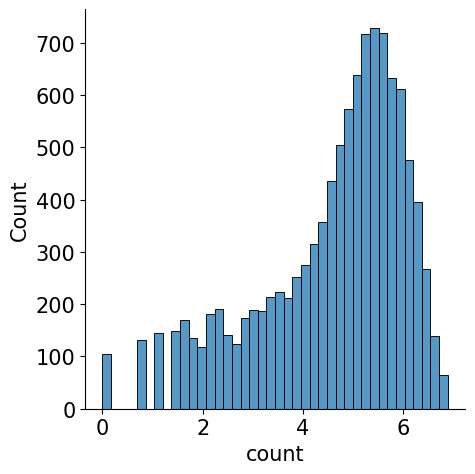

In [41]:
# 회귀 모델이 좋은 성능을 내려면 데이터가 정규분포를 따라야 한다.
# 데이터 분포를 정규분포에 가깝게 만들기 위해 주로 로그변환을 사용한다.
# 로그변환은 count 분포와 같이 데이터가 왼쪽으로 편향되어 있을 때 사용한다.

sns.displot(np.log(train["count"]));

In [42]:
# 피처를 log 씌워서 그래프를 그렸기 때문에 log(count) 를 예측하는 것이 더 정확하다. 
# 따라서 타깃값을 log(count) 로 변환하여 사용한다.

# !!!! 마지막에 지수변환을 하여 실제 타깃값인 count 로 복원을 해야한다.

### 막대 그래프

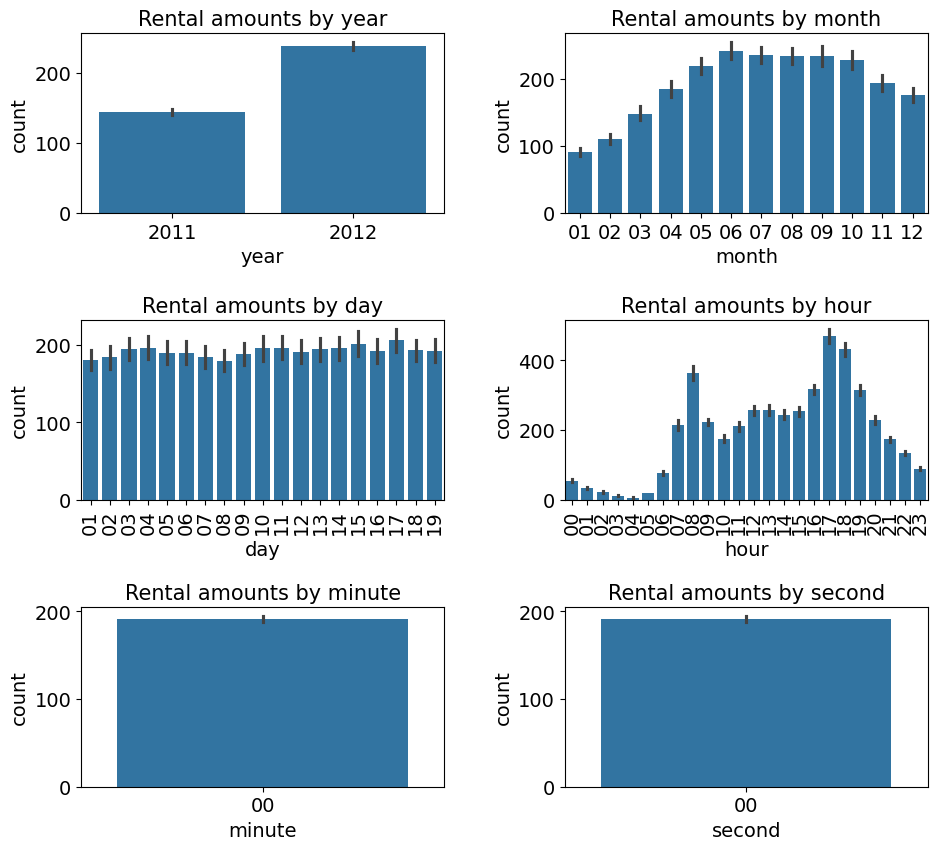

In [55]:
mpl.rc("font", size=14)
mpl.rc("axes", titlesize=15)

figure, axes = plt.subplots(nrows=3, ncols=2)
plt.tight_layout()
figure.set_size_inches(10, 9)

sns.barplot(x="year", y="count", data=train, ax=axes[0, 0])
sns.barplot(x="month", y="count", data=train, ax=axes[0, 1])
sns.barplot(x="day", y="count", data=train, ax=axes[1, 0])
sns.barplot(x="hour", y="count", data=train, ax=axes[1, 1])
sns.barplot(x="minute", y="count", data=train, ax=axes[2, 0])
sns.barplot(x="second", y="count", data=train, ax=axes[2, 1])

axes[0, 0].set(title="Rental amounts by year")
axes[0, 1].set(title="Rental amounts by month")
axes[1, 0].set(title="Rental amounts by day")
axes[1, 1].set(title="Rental amounts by hour")
axes[2, 0].set(title="Rental amounts by minute")
axes[2, 1].set(title="Rental amounts by second")

axes[1, 0].tick_params(axis='x', labelrotation=90)
axes[1, 1].tick_params(axis='x', labelrotation=90)


### 박스플롯

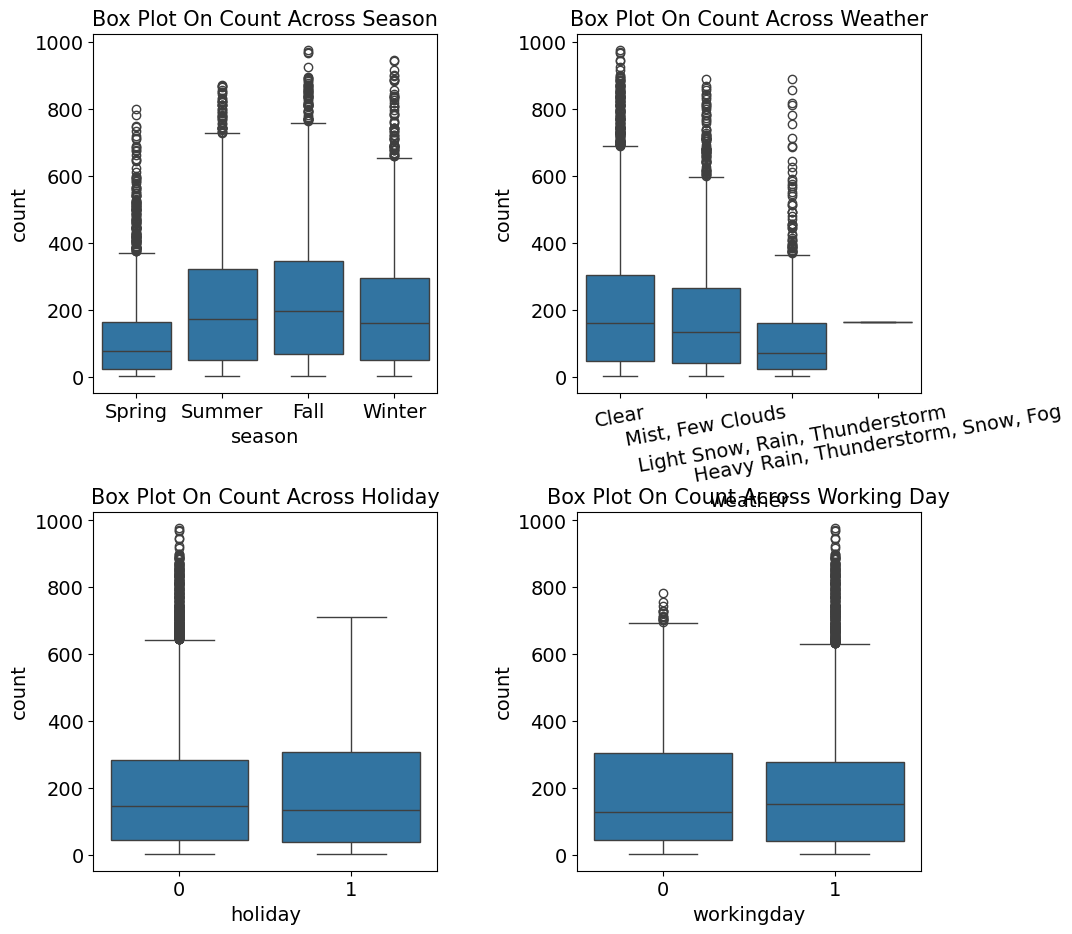

In [56]:
figure, axes = plt.subplots(nrows=2, ncols=2)
plt.tight_layout()
figure.set_size_inches(10, 10)

sns.boxplot(x="season", y="count", data=train, ax=axes[0, 0])
sns.boxplot(x="weather", y="count", data=train, ax=axes[0, 1])
sns.boxplot(x="holiday", y="count", data=train, ax=axes[1, 0])
sns.boxplot(x="workingday", y="count", data=train, ax=axes[1, 1])

axes[0, 0].set(title="Box Plot On Count Across Season")
axes[0, 1].set(title="Box Plot On Count Across Weather")
axes[1, 0].set(title="Box Plot On Count Across Holiday")
axes[1, 1].set(title="Box Plot On Count Across Working Day")

axes[0, 1].tick_params(axis='x', labelrotation=10)


### 포인트플롯

<Axes: xlabel='hour', ylabel='count'>

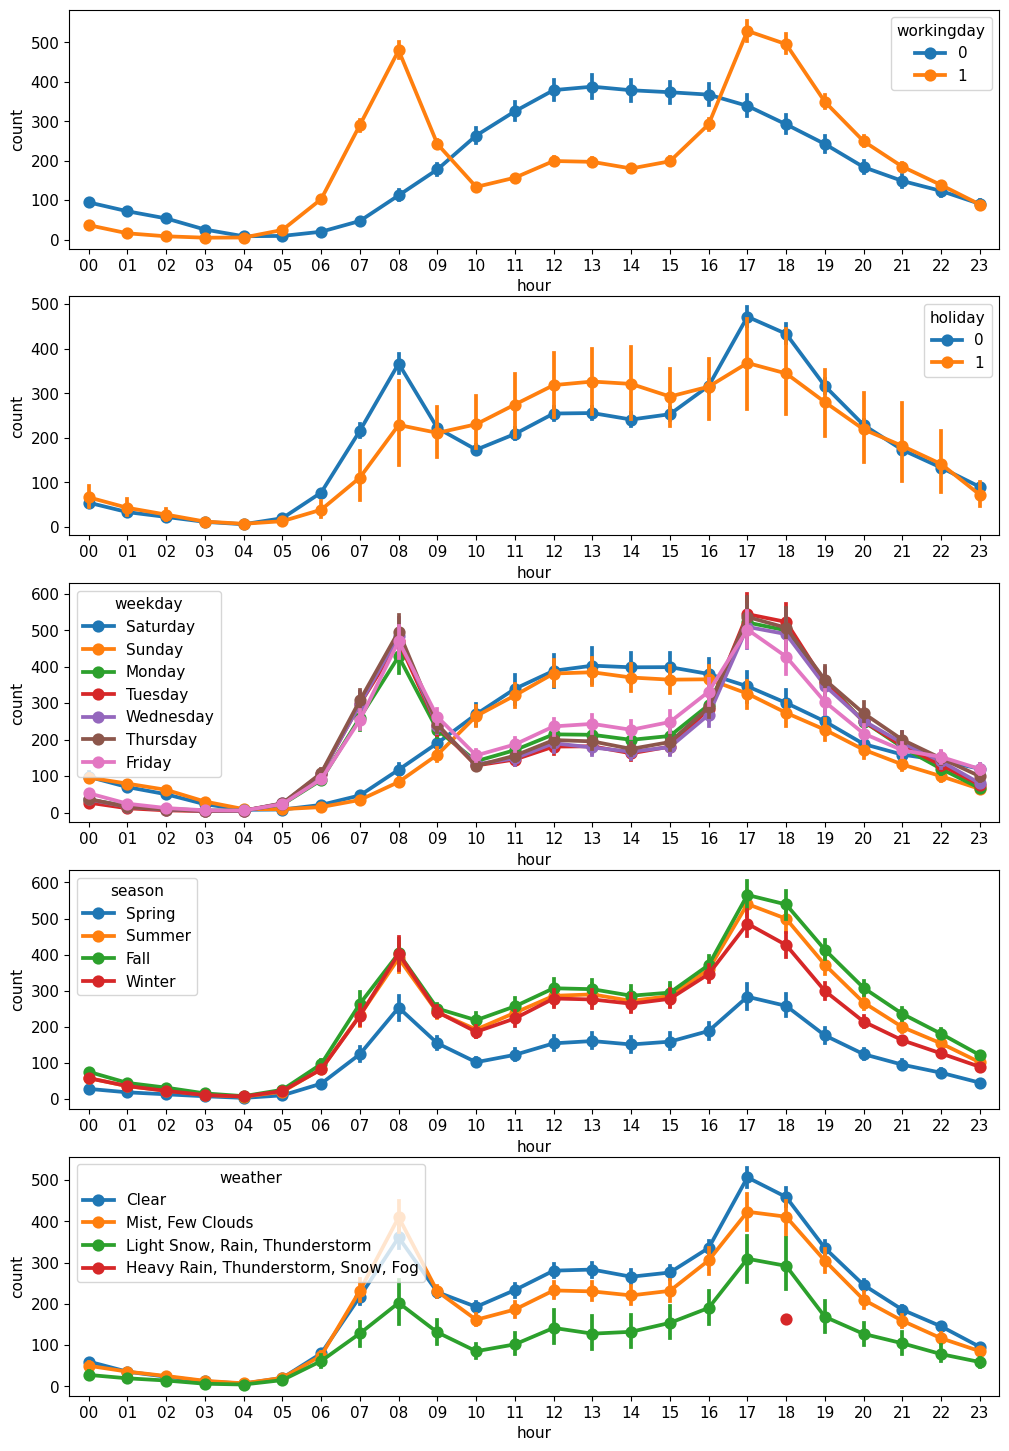

In [58]:
mpl.rc("font", size=11)
figure, axes = plt.subplots(nrows=5)
figure.set_size_inches(12, 18)

sns.pointplot(x="hour", y="count", data=train, hue="workingday", ax=axes[0])
sns.pointplot(x="hour", y="count", data=train, hue="holiday", ax=axes[1])
sns.pointplot(x="hour", y="count", data=train, hue="weekday", ax=axes[2])
sns.pointplot(x="hour", y="count", data=train, hue="season", ax=axes[3])
sns.pointplot(x="hour", y="count", data=train, hue="weather", ax=axes[4])


### 회귀선을 포함한 산점도 그래프

<Axes: xlabel='humidity', ylabel='count'>

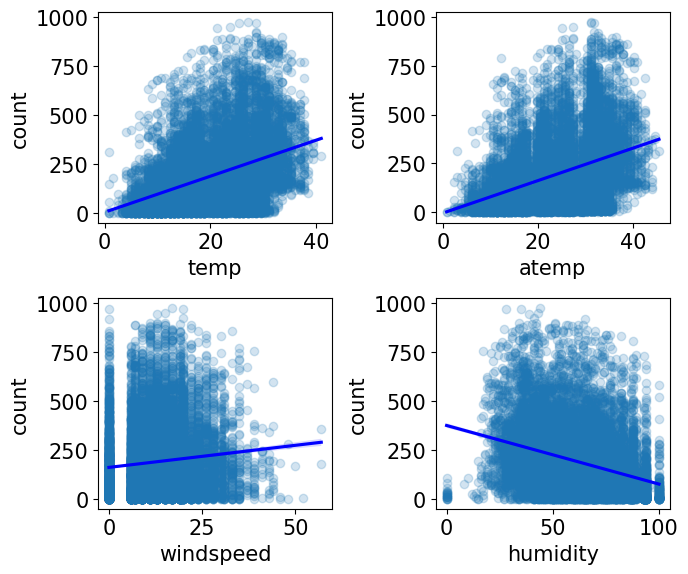

In [61]:
mpl.rc("font", size=15)
figure, axes = plt.subplots(nrows=2, ncols=2)
plt.tight_layout()
figure.set_size_inches(7, 6)

sns.regplot(x="temp", y="count", data=train, ax=axes[0, 0], scatter_kws={"alpha": 0.2}, line_kws={"color" : "blue"})
sns.regplot(x="atemp", y="count", data=train, ax=axes[0, 1], scatter_kws={"alpha": 0.2}, line_kws={"color" : "blue"})
sns.regplot(x="windspeed", y="count", data=train, ax=axes[1, 0], scatter_kws={"alpha": 0.2}, line_kws={"color" : "blue"})
sns.regplot(x="humidity", y="count", data=train, ax=axes[1, 1], scatter_kws={"alpha": 0.2}, line_kws={"color" : "blue"})


### 히트맵


In [ ]:
# 수치형 데이터인 아래의 데이터들끼리 어떤 상관관계가 있는지 알아본다.
train[["temp", "atemp", "humidity", "windspeed", "count"]].corr()

,temp,atemp,humidity,windspeed,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.101369
count,0.394454,0.389784,-0.317371,0.101369,1.000000


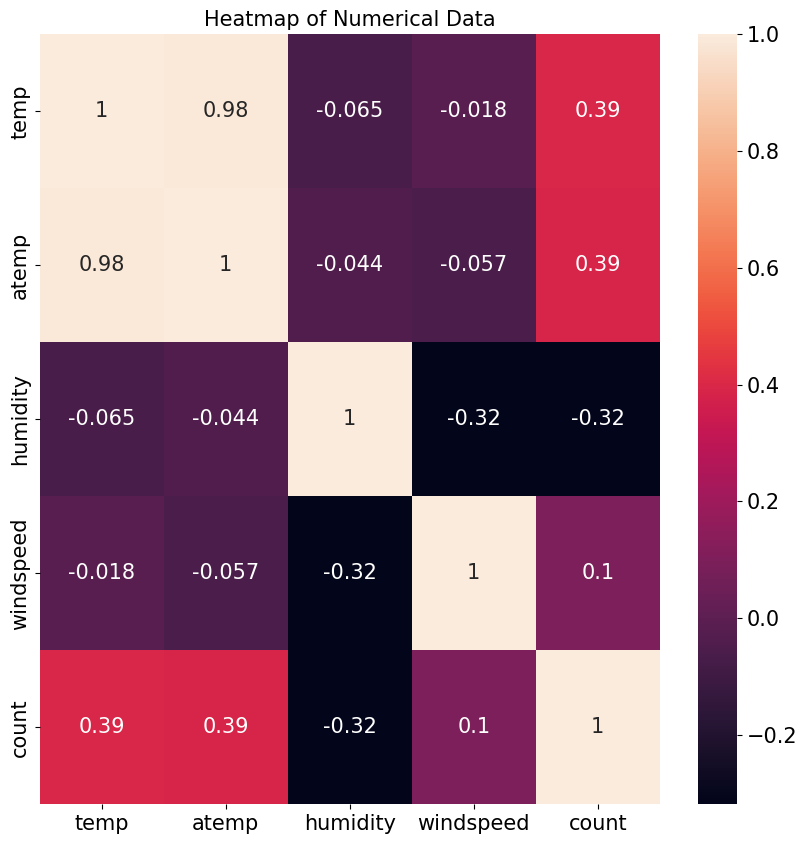

In [65]:
corrMat = train[["temp", "atemp", "humidity", "windspeed", "count"]].corr()
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sns.heatmap(corrMat, annot=True)
ax.set(title="Heatmap of Numerical Data");

## 요약 및 분석

### 1. 데이터 구조
- `train.csv`에는 정답 변수 `count`가 있고, `test.csv`에는 `count`가 없다.
- 따라서 이 문제는 과거 데이터로 자전거 대여 수를 예측하는 회귀 문제다.
- `count`는 `casual + registered`와 정확히 일치하는 총 대여 수다.

### 2. `datetime` 피처 처리
- `datetime`은 문자열이기 때문에 날짜와 시간을 분리해 새 피처를 만들었다.
- `date`, `year`, `month`, `day`, `hour`, `minute`, `second`를 추출하는 방식이다.
- 이때 `lambda`는 각 행의 문자열을 한 번씩 처리하는 짧은 함수로 사용됐다.
- 다만 `minute`, `second`는 대부분 `00`이라 실제 모델링에서는 정보가 거의 없다.

### 3. 요일 피처 생성
- `date`를 `datetime.strptime()`로 날짜 형식으로 바꾼 뒤 `weekday()`와 `calendar.day_name`으로 요일 이름을 만들었다.
- 이것은 날짜 정보에서 계절성/주기성을 더 잘 반영하기 위한 전처리다.

### 4. 범주형 값 해석
- `season`과 `weather`는 숫자 코드로 들어 있으므로 사람이 읽기 쉬운 문자열로 매핑했다.
- `weather`는 원본 데이터에서 결측값이 아니라 `1~4`의 코드값이다.
- `train`과 `test` 모두 `weather` 값이 존재하며, 둘 다 같은 기준으로 다루는 것이 좋다.

### 5. 분포와 로그변환
- `count`는 오른쪽으로 긴 꼬리를 가진 분포라서 `np.log(train["count"])`로 변환해 분포를 완화했다.
- 로그변환은 회귀 모델이 더 안정적으로 학습하도록 돕는다.
- 예측이 끝나면 `np.exp()`로 다시 원래 `count` 스케일로 복원해야 한다.

### 6. 시각화 해석
- 막대그래프와 산점도는 `year`, `month`, `day`, `hour`, `temp`, `atemp`, `humidity`, `windspeed`와 `count`의 관계를 확인하려는 목적이다.
- `hour`는 의미가 크지만 `minute`, `second`는 거의 모두 0이라 정보량이 낮다.
- `temp`와 `atemp`는 상관이 매우 높고, `humidity`는 `count`와 음의 상관을 보인다.

### 7. 코드상 주의점
- 히트맵 셀에서 `humity`는 오타이고 `humidity`가 맞다.
- 따라서 상관행렬을 만들 때 컬럼명을 정확히 써야 에러가 나지 않는다.
- `train`에만 적용한 문자열 변환이나 피처 생성은 `test`에도 같은 규칙으로 맞추는 것이 안전하다.

### 8. 전체 흐름 정리
- 원본 문자열/범주형 값을 분해해서 모델이 학습할 수 있는 숫자형 피처로 바꾸는 과정이 핵심이다.
- 이 노트북의 목적은 단순한 탐색이 아니라, `count` 예측에 유효한 피처를 찾고 전처리하는 것이다.
